In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import plot_tree

In [2]:
github_raw_url = "https://raw.githubusercontent.com/soumitra45-git/AI-ML-LAB-3/refs/heads/main/DT/iris.csv"

df = pd.read_csv(github_raw_url)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (150, 5)

Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [4]:
imputer = SimpleImputer(strategy='mean')

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [5]:
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [6]:
X = df.drop('species', axis=1)
y = df['species']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [8]:
cart = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

param_grid = {
    'max_depth':[2,3,4,5,6,None],
    'min_samples_split':[2,4,6,8,10]
}

cart_grid = GridSearchCV(
    cart,
    param_grid,
    cv=5,
    scoring='accuracy'
)

cart_grid.fit(X_train, y_train)

print("Best CART Parameters:")
print(cart_grid.best_params_)

Best CART Parameters:
{'max_depth': 4, 'min_samples_split': 2}


In [9]:
cart_best = cart_grid.best_estimator_

cart_pred = cart_best.predict(X_test)

In [10]:
id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

id3_grid = GridSearchCV(
    id3,
    param_grid,
    cv=5,
    scoring='accuracy'
)

id3_grid.fit(X_train, y_train)

print("Best ID3 Parameters:")
print(id3_grid.best_params_)

Best ID3 Parameters:
{'max_depth': 5, 'min_samples_split': 2}


In [11]:
id3_best = id3_grid.best_estimator_

id3_pred = id3_best.predict(X_test)

In [12]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true,y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    return [accuracy,precision,recall,f1]

In [13]:
cart_metrics = evaluate_model(y_test, cart_pred)
id3_metrics = evaluate_model(y_test, id3_pred)

metrics_df = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1'],
    'CART':cart_metrics,
    'ID3':id3_metrics
})

print(metrics_df)

      Metric      CART       ID3
0   Accuracy  0.933333  0.933333
1  Precision  0.933333  0.933333
2     Recall  0.933333  0.933333
3         F1  0.933333  0.933333


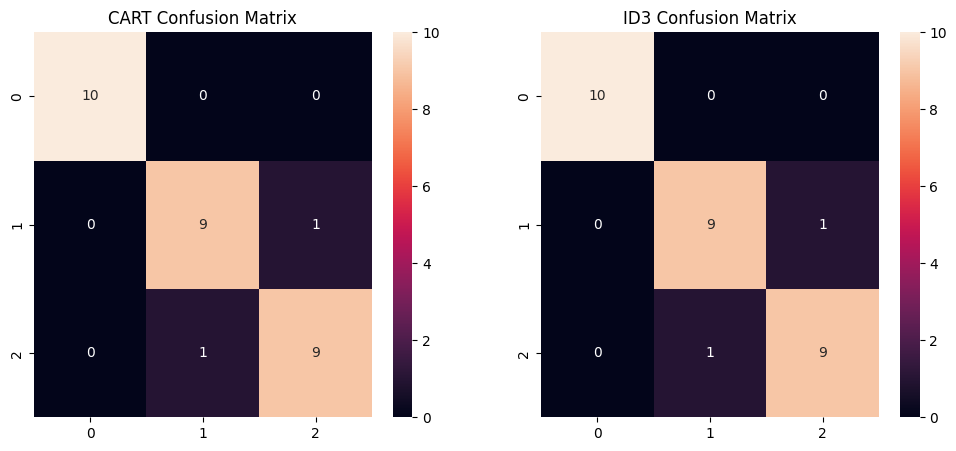

In [14]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test, cart_pred),
    annot=True,
    fmt='d',
    ax=axes[0]
)

axes[0].set_title("CART Confusion Matrix")

sns.heatmap(
    confusion_matrix(y_test, id3_pred),
    annot=True,
    fmt='d',
    ax=axes[1]
)

axes[1].set_title("ID3 Confusion Matrix")

plt.show()

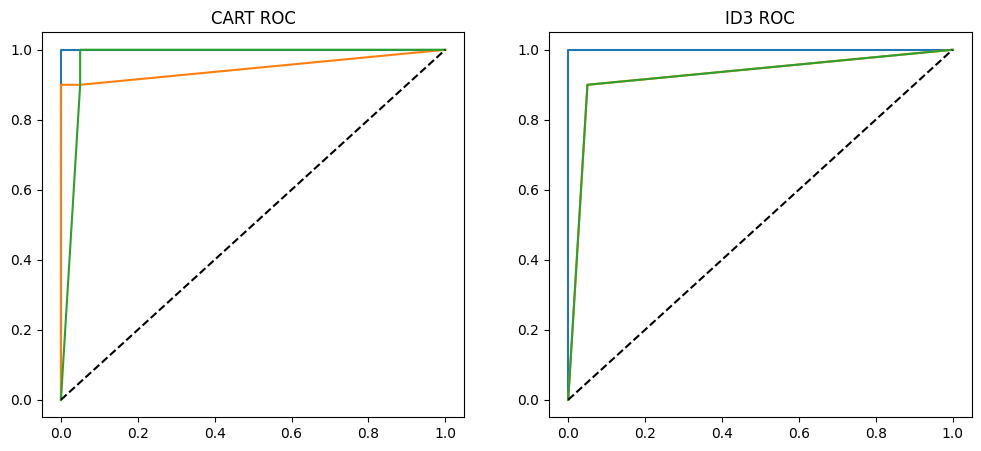

In [15]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

cart_prob = cart_best.predict_proba(X_test)
id3_prob = id3_best.predict_proba(X_test)

fig, axes = plt.subplots(1,2,figsize=(12,5))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        cart_prob[:,i]
    )

    axes[0].plot(fpr,tpr)

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("CART ROC")

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_test_bin[:,i],
        id3_prob[:,i]
    )

    axes[1].plot(fpr,tpr)

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("ID3 ROC")

plt.show()

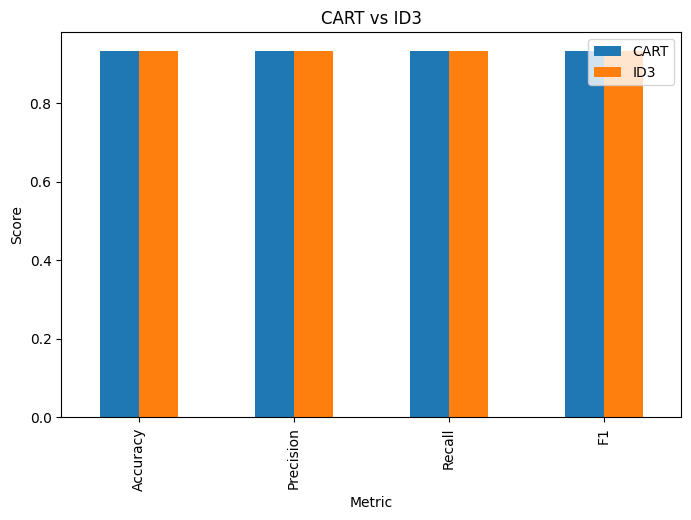

In [16]:
metrics_df.set_index('Metric').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("CART vs ID3")
plt.ylabel("Score")

plt.show()

In [17]:
X_vis = X[['sepal_length','sepal_width']]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


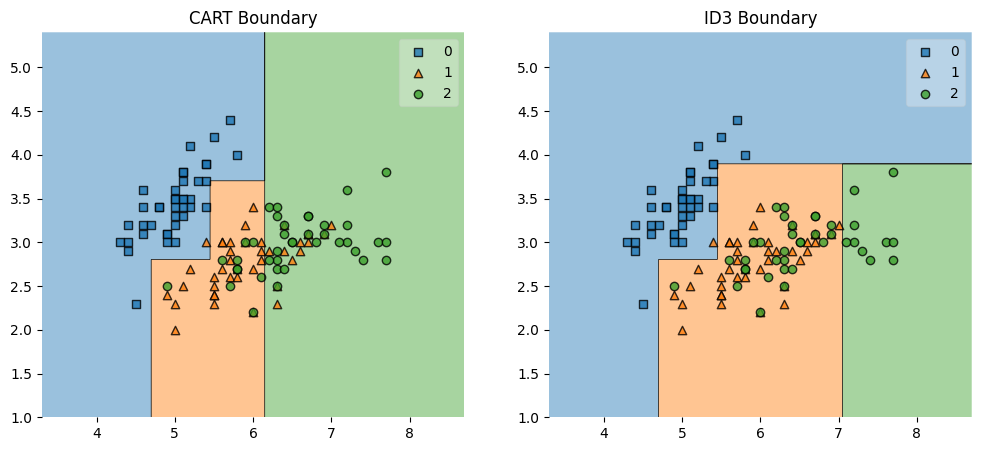

In [18]:
from mlxtend.plotting import plot_decision_regions

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis,
    y,
    test_size=0.2,
    random_state=42
)

cart_vis = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3
)

cart_vis.fit(X_train_v,y_train_v)

id3_vis = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

id3_vis.fit(X_train_v,y_train_v)

fig, axes = plt.subplots(1,2,figsize=(12,5))

plot_decision_regions(
    X_train_v.values,
    y_train_v.values,
    clf=cart_vis,
    ax=axes[0]
)

axes[0].set_title("CART Boundary")

plot_decision_regions(
    X_train_v.values,
    y_train_v.values,
    clf=id3_vis,
    ax=axes[1]
)

axes[1].set_title("ID3 Boundary")

plt.show()

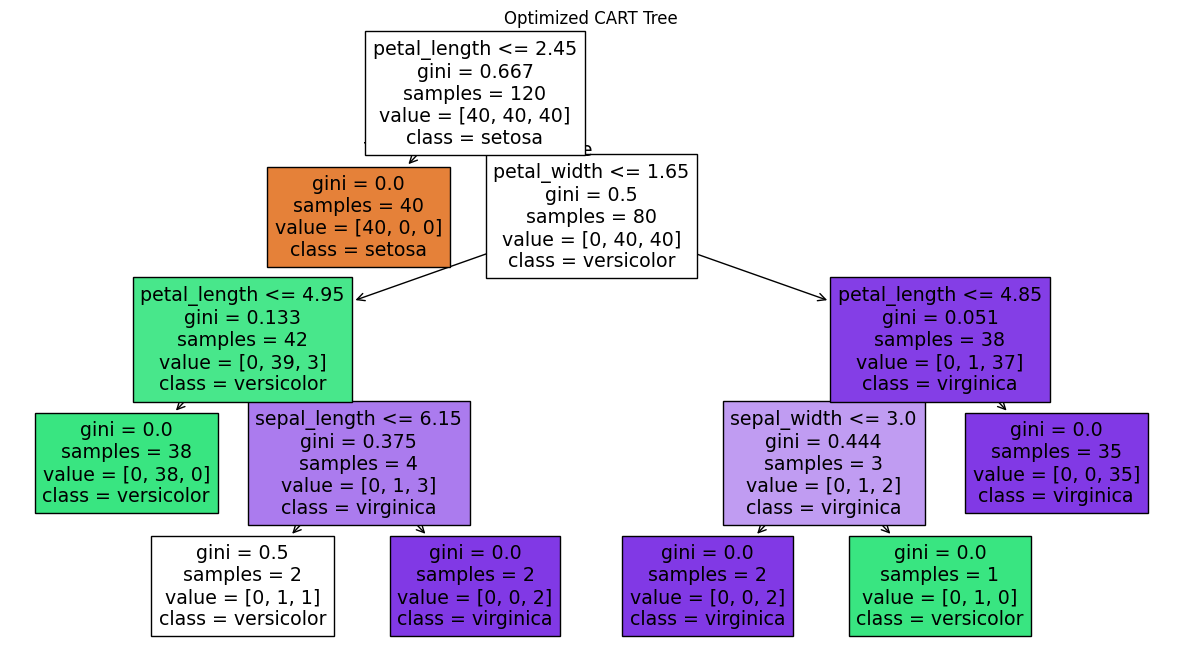

In [19]:
plt.figure(figsize=(15,8))

plot_tree(
    cart_best,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True
)

plt.title("Optimized CART Tree")

plt.show()